<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_13_4_pruning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks
**Module 13: Other Techniques**  

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 13 Material

* Part 13.1: Autoencoders and Dimensionality Reduction [[Notebook]](t81_558_class_13_1_auto_encode.ipynb)
* Part 13.2: Anomaly Detection [[Notebook]](t81_558_class_13_2_anomaly.ipynb)
* Part 13.3: Reinforcement Learning with TorchRL [[Notebook]](t81_558_class_13_3_reinforcement.ipynb)
* **Part 13.4: Pruning Neural Networks** [[Notebook]](t81_558_class_13_4_pruning.ipynb)
* Part 13.5: Self-Supervised Learning [[Notebook]](t81_558_class_13_5_self_supervised.ipynb)

# Google CoLab Instructions

The following code checks that Google CoLab is running and sets up the correct hardware settings for PyTorch.

In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

# Make use of a GPU or MPS (Apple) if one is available.  (see module 2.5)
import torch
has_mps = torch.backends.mps.is_built()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: not using Google CoLab


Using device: mps


# Part 13.4: Pruning Neural Networks

Trained neural networks are usually far larger than they need to be. Many of their weights end up close to zero and contribute almost nothing to the output, a form of redundancy that the training process tolerates but does not require. **Pruning** is the practice of removing these unimportant weights or neurons to produce a smaller, faster model. A pruned network takes less memory to store, can be cheaper to run, and is easier to deploy on phones, microcontrollers, and other resource-constrained hardware, often with little or no loss in accuracy.

The idea is supported by a striking empirical finding known as the *lottery ticket hypothesis*: a large trained network typically contains a much smaller subnetwork that, on its own, can match the full network's accuracy. Pruning is how we search for that subnetwork. The simplest and most widely used strategy is **magnitude pruning**, which assumes that a weight's importance is reflected in its absolute value and removes the smallest ones.

This section demonstrates pruning with PyTorch's built-in `torch.nn.utils.prune` utilities. We train a classifier on handwritten digits, prune away increasing fractions of its weights, and chart how accuracy holds up as the network is thinned. We then show that a brief round of fine-tuning after pruning recovers most of the accuracy lost at aggressive sparsity levels.

## What Gets Pruned

Pruning methods differ along two axes. The first is *what* is removed. **Unstructured pruning** zeros out individual weights scattered throughout a layer, producing a sparse weight matrix. This can reach very high sparsity with little accuracy loss, but realizing the speed-up requires hardware or libraries that exploit sparsity. **Structured pruning** removes whole units, entire neurons, channels, or filters, which shrinks the network's dense dimensions directly and speeds it up on ordinary hardware, at the cost of being coarser and usually more damaging per parameter removed.

The second axis is *how importance is judged*. **Magnitude pruning** ranks weights by absolute value and removes the smallest, on the assumption that near-zero weights matter least. More elaborate criteria exist, using gradients or second-order information, but magnitude pruning is simple, cheap, and a strong baseline that remains standard practice.

We will use unstructured magnitude pruning, the most common combination, and measure the accuracy-versus-sparsity tradeoff. First we train a network to prune.

In [2]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

torch.manual_seed(42)
np.random.seed(42)

digits = load_digits()
X = MinMaxScaler().fit_transform(digits.data).astype(np.float32)
y = digits.target.astype(np.int64)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_tr_t, y_tr_t = torch.tensor(X_tr), torch.tensor(y_tr)
X_te_t, y_te_t = torch.tensor(X_te), torch.tensor(y_te)


class DigitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(64, 128)
        self.fc2 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 10)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        return self.out(x)


def train(model, epochs=300):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        opt.zero_grad()
        loss_fn(model(X_tr_t), y_tr_t).backward()
        opt.step()
    return model


def accuracy(model):
    with torch.no_grad():
        return (model(X_te_t).argmax(1) == y_te_t).float().mean().item()


model = train(DigitNet())
print(f"Baseline test accuracy: {accuracy(model):.4f}")
total = sum(p.numel() for n, p in model.named_parameters() if "weight" in n)
print(f"Total weight parameters: {total}")

Baseline test accuracy: 0.9722
Total weight parameters: 17024


## Magnitude Pruning at Increasing Sparsity

PyTorch's `prune` module applies pruning by attaching a binary mask to a parameter that zeros out the selected weights. The function `prune.l1_unstructured` removes a given fraction of the smallest-magnitude weights from a layer. To measure the tradeoff, we prune copies of the trained network to a range of sparsity levels, from untouched up to almost entirely removed, and record the test accuracy at each level.

Note that we prune a fresh copy of the original model at each level rather than pruning cumulatively, so that each measurement reflects that sparsity applied to the fully trained network.

In [3]:
import copy

def prune_model(base, amount):
    m = copy.deepcopy(base)
    for layer in [m.fc1, m.fc2, m.out]:
        prune.l1_unstructured(layer, name="weight", amount=amount)
    return m


def sparsity(model):
    # Count zeros in the effective (masked) weights of the pruned layers.
    zeros = total = 0
    for layer in [model.fc1, model.fc2, model.out]:
        w = layer.weight
        zeros += int((w == 0).sum())
        total += w.numel()
    return zeros / total


amounts = [0.0, 0.25, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
results = []
for a in amounts:
    pruned = prune_model(model, a)
    results.append((sparsity(pruned), accuracy(pruned)))
    print(f"prune {a:4.0%}  ->  sparsity {results[-1][0]:5.1%}   accuracy {results[-1][1]:.4f}")

prune   0%  ->  sparsity  0.0%   accuracy 0.9722
prune  25%  ->  sparsity 25.0%   accuracy 0.9704
prune  50%  ->  sparsity 50.0%   accuracy 0.9278
prune  60%  ->  sparsity 60.0%   accuracy 0.8722
prune  70%  ->  sparsity 70.0%   accuracy 0.7981
prune  80%  ->  sparsity 80.0%   accuracy 0.4741
prune  90%  ->  sparsity 90.0%   accuracy 0.3093
prune  95%  ->  sparsity 95.0%   accuracy 0.1593
prune  99%  ->  sparsity 99.0%   accuracy 0.1000


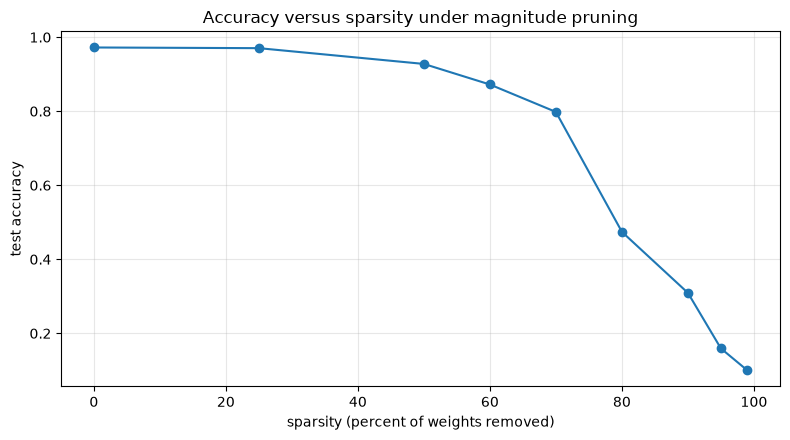

In [4]:
spars = [s for s, _ in results]
accs = [a for _, a in results]

plt.figure(figsize=(8, 4.5))
plt.plot([s * 100 for s in spars], accs, "o-")
plt.xlabel("sparsity (percent of weights removed)")
plt.ylabel("test accuracy")
plt.title("Accuracy versus sparsity under magnitude pruning")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The curve reveals the central fact about pruning: accuracy holds up remarkably well while the first quarter of the weights are removed, stays high even at half sparsity, and only then begins to decline before collapsing once pruning grows extreme. The near-flat early region is the redundancy, the network genuinely did not need those weights. The cliff on the right is where pruning starts deleting weights the network actually relies on. The practical goal is to operate near the end of the flat region, capturing most of the size and speed benefit before accuracy suffers.

## Recovering Accuracy with Fine-Tuning

At very high sparsity the pruned network loses accuracy, but much of that loss can be recovered by **fine-tuning**: continuing to train the pruned network for a few more epochs. The remaining weights adjust to compensate for the ones that were removed. In practice, pruning is often done *iteratively*, alternating between removing a portion of the weights and fine-tuning, which reaches higher sparsity with less damage than pruning everything at once.

We take the aggressively pruned 90-percent-sparse network and fine-tune it. The pruning mask stays in place, so the zeroed weights remain zero; only the surviving weights are updated.

In [5]:
pruned = prune_model(model, 0.90)
print(f"before fine-tuning:  sparsity {sparsity(pruned):.1%}   accuracy {accuracy(pruned):.4f}")

# Fine-tune the surviving weights. The pruning masks keep pruned weights at zero.
opt = torch.optim.Adam(pruned.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
for _ in range(500):
    opt.zero_grad()
    loss_fn(pruned(X_tr_t), y_tr_t).backward()
    opt.step()

print(f"after  fine-tuning:  sparsity {sparsity(pruned):.1%}   accuracy {accuracy(pruned):.4f}")

before fine-tuning:  sparsity 90.0%   accuracy 0.3093


after  fine-tuning:  sparsity 90.0%   accuracy 0.9463


Fine-tuning restores the 90-percent-sparse network to nearly its original accuracy, showing that a network keeping only a tenth of its weights can still perform well once the survivors are given a chance to adapt. This is the lottery-ticket subnetwork in action: a compact model hidden inside the large one, recoverable through pruning and a little retraining.

Pruning is one of several techniques, alongside quantization and knowledge distillation, for compressing networks for efficient deployment. The final section of this module explores a very different frontier, learning useful representations without labels at all: [Self-Supervised Learning](t81_558_class_13_5_self_supervised.ipynb).